# M5 Subset EDA

Exploring the 100-series subset built by `src/data_prep.py` before training Prophet: weekly seasonality, trend, and holiday/event effects.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/subset_long.csv", parse_dates=["date"])
print(df.shape)
df.head()


(191300, 21)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,wday,month,year,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,FOODS_1_218_TX_2_validation,FOODS_1_218,FOODS_1,FOODS,TX_2,TX,d_1,5,2011-01-29,11101,...,1,1,2011,NaN,NaN,NaN,NaN,0,0,0
1,FOODS_1_218_TX_2_validation,FOODS_1_218,FOODS_1,FOODS,TX_2,TX,d_2,3,2011-01-30,11101,...,2,1,2011,NaN,NaN,NaN,NaN,0,0,0
2,FOODS_1_218_TX_2_validation,FOODS_1_218,FOODS_1,FOODS,TX_2,TX,d_3,2,2011-01-31,11101,...,3,1,2011,NaN,NaN,NaN,NaN,0,0,0
3,FOODS_1_218_TX_2_validation,FOODS_1_218,FOODS_1,FOODS,TX_2,TX,d_4,1,2011-02-01,11101,...,4,2,2011,NaN,NaN,NaN,NaN,1,1,0
4,FOODS_1_218_TX_2_validation,FOODS_1_218,FOODS_1,FOODS,TX_2,TX,d_5,4,2011-02-02,11101,...,5,2,2011,NaN,NaN,NaN,NaN,1,0,1


## Weekly seasonality

Average sales by day of week, aggregated across all 100 series. `calendar.csv`
already provides a human-readable `weekday` string column, so we use that
directly rather than decoding M5's `wday` integer (which follows Walmart's
fiscal week starting Saturday, not the calendar week).

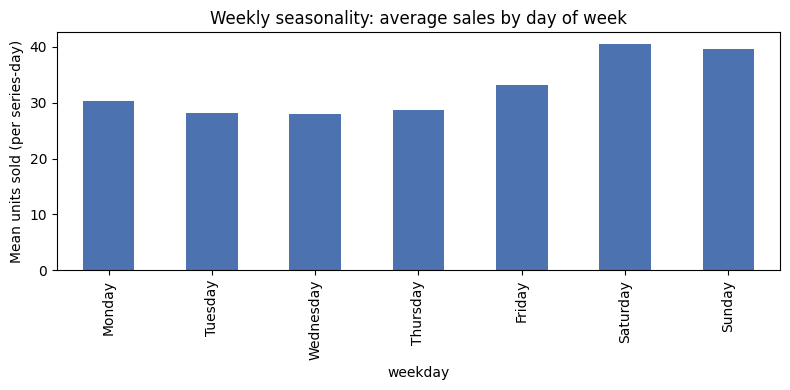

weekday
Monday       30.360147
Tuesday      28.130513
Wednesday    27.920989
Thursday     28.758242
Friday       33.093333
Saturday     40.567518
Sunday       39.549453
Name: sales, dtype: float64

In [2]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly = df.groupby("weekday")["sales"].mean().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(8, 4))
weekly.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Mean units sold (per series-day)")
ax.set_title("Weekly seasonality: average sales by day of week")
plt.tight_layout()
plt.savefig("../results/eda_weekly_seasonality.png", dpi=120)
plt.show()

weekly


## Trend

Daily total sales across all 100 series, with a 28-day rolling average to
smooth out day-to-day noise and reveal the underlying trend.

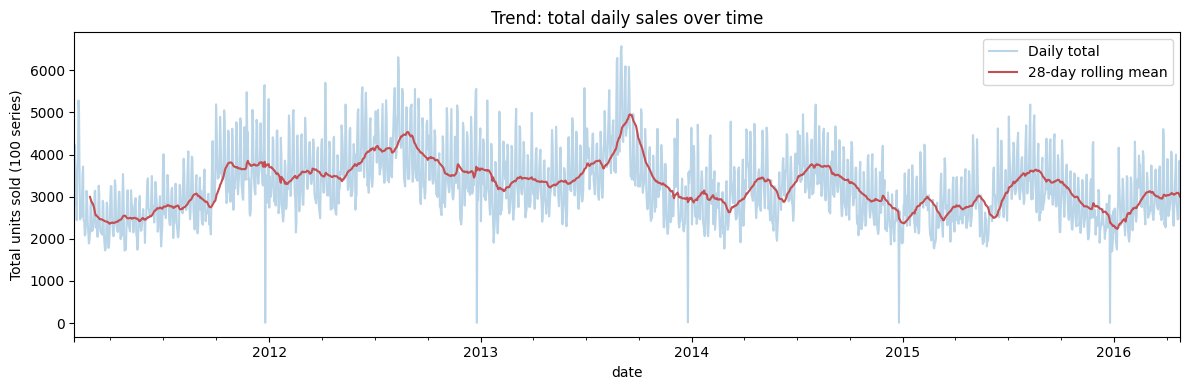

In [3]:
daily_total = df.groupby("date")["sales"].sum()
rolling = daily_total.rolling(28).mean()

fig, ax = plt.subplots(figsize=(12, 4))
daily_total.plot(ax=ax, alpha=0.3, label="Daily total")
rolling.plot(ax=ax, color="#C44E52", label="28-day rolling mean")
ax.set_ylabel("Total units sold (100 series)")
ax.set_title("Trend: total daily sales over time")
ax.legend()
plt.tight_layout()
plt.savefig("../results/eda_trend.png", dpi=120)
plt.show()


## Holiday / event effects

`calendar.csv` flags specific dates with `event_name_1` / `event_type_1`
(e.g. SuperBowl, Thanksgiving, Christmas). We compare mean sales on event
days vs. non-event days to see whether events are worth passing to Prophet
as holiday regressors, or whether the effect is negligible for this
FOODS/HOUSEHOLD-heavy subset.

In [4]:
df["has_event"] = df["event_name_1"].notna()
event_effect = df.groupby("has_event")["sales"].mean()
print(event_effect)

by_event_type = (
    df[df["has_event"]]
    .groupby("event_type_1")["sales"]
    .mean()
    .sort_values(ascending=False)
)
by_event_type


has_event
False    32.662933
True     32.297468
Name: sales, dtype: float64


event_type_1
Sporting     35.348750
Cultural     34.475429
Religious    31.763269
National     30.390196
Name: sales, dtype: float64

## SNAP effect

`snap_CA/TX/WI` flag days when SNAP (food assistance) purchases are allowed
in that state. Since our subset is FOODS-heavy, we'd expect a real bump on
SNAP days — worth checking per-state using each series' own `state_id`
rather than a single flat SNAP column.

In [5]:
def row_is_snap_day(row):
    return bool(row[f"snap_{row['state_id']}"])

df["is_snap_day"] = df.apply(row_is_snap_day, axis=1)
df.groupby(["state_id", "is_snap_day"])["sales"].mean().unstack()


is_snap_day,False,True
state_id,,
CA,30.626881,33.747972
TX,35.905456,38.174921
WI,27.040343,34.728063


## Individual series shape

Aggregates hide what Prophet actually has to fit per-series. Plotting a
few individual series (not the 100-series total) to sanity-check for
intermittency, outliers, or structural breaks before training.

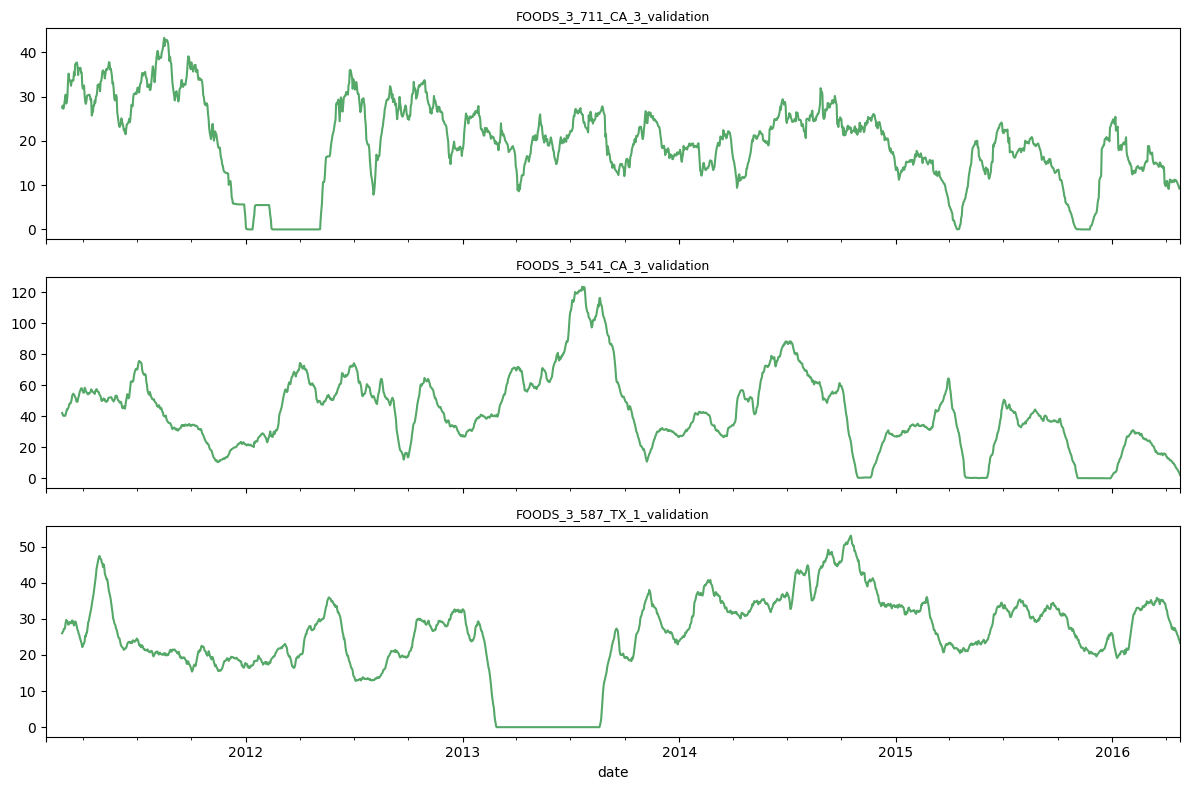

In [6]:
sample_ids = df["id"].drop_duplicates().sample(3, random_state=42)

fig, axes = plt.subplots(len(sample_ids), 1, figsize=(12, 8), sharex=True)
for ax, series_id in zip(axes, sample_ids):
    s = df[df["id"] == series_id].set_index("date")["sales"]
    s.rolling(28).mean().plot(ax=ax, color="#55A868")
    ax.set_title(series_id, fontsize=9)
plt.tight_layout()
plt.savefig("../results/eda_sample_series.png", dpi=120)
plt.show()
